# This is an example notebook for ring spreading test

After building ``RAPID``, the executable binary ``simulation`` is located in the bin folder.


In [2]:
import subprocess
import os

# ensure we run from project root if notebook is inside "notebooks"
cwd = os.getcwd()
if os.path.basename(cwd) == "notebooks":
    os.chdir("..")

yaml_files = [
    "notebooks/configs/ring_viscosity_test.yaml"
]

for yaml_path in yaml_files:
    print("\n==============================================")
    print(f"Running simulation for: {yaml_path}")
    print("==============================================\n")

    cmd = [
        "python3",
        "run_simulation.py",
        "--config",
        yaml_path
    ]

    process = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)

    for line in process.stdout:
        print(line.rstrip("\n"))

    process.wait()

    print(f"\nSimulation finished for: {yaml_path}\n")



Running simulation for: notebooks/configs/ring_viscosity_test.yaml

[PY-WRAPPER] Terminal panels disabled (YAML setting).

[PY-WRAPPER] --- Running: Main Simulation Program ---
[PY-WRAPPER] The current command-line arguments are:
 ./bin/simulation -v -no_panels -evol 1.0 -test ring_viscosity -n 200 -ri 0.5 -ro 25.0 -disk_mass 0.01 -alpha_init 0.3 -stellar_mass 1.0 -inner_bc parabolic -outer_bc reflecting -o notebooks/ring_viscosity_test/ring_viscosity_test -tmax 100000.0 -outfreq 20000.0
[PY-WRAPPER] Setting OMP_NUM_THREADS=1 for this run.
[PY-WRAPPER] Start running the binary (./bin/simulation) at 2026-09-15 19:20:17...

||                                                                      ||
||                        RAPID SIMULATION CORE                         ||
||                            Version: 2.2.4                            ||
||                                                                      ||
||                  Lead Developer: [D. Tarczay-Nehez]               

## Viscous spreading of a ring

Changed directory to: ./notebooks
Profile evolution plot saved to: ring_viscosity_test/ring_viscosity_test/ring_profiles_evolution_plot.png


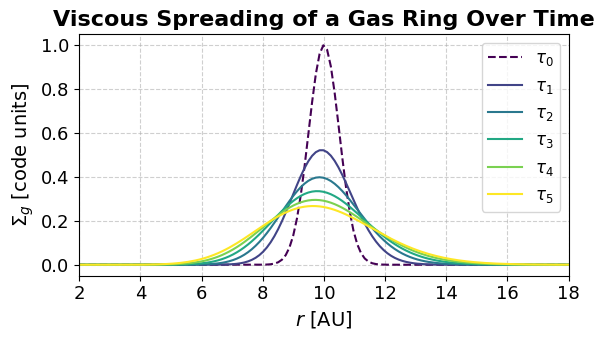

In [3]:
import glob
import time
import numpy as np
import matplotlib.pyplot as plt

import os

# current working directory
cwd = os.getcwd()

# if we are NOT inside notebooks, try to find it
if os.path.basename(cwd) != "notebooks":
    # search for a notebooks directory in the current tree
    for root, dirs, files in os.walk(".", topdown=True):
        if "notebooks" in dirs:
            notebooks_path = os.path.join(root, "notebooks")
            os.chdir(notebooks_path)
            print(f"Changed directory to: {notebooks_path}")
            break
    else:
        print("No 'notebooks' directory found. Staying in current directory.")
else:
    print("Already inside notebooks.")


def safe_loadtxt(path, retries=20, delay=0.2):
    for attempt in range(retries):
        try:
            return np.loadtxt(path)
        except Exception:
            time.sleep(delay)
    print(f"WARNING: Could not fully read file after {retries} attempts: {path}")
    return None

output_dir = "ring_viscosity_test/ring_viscosity_test"
logs_dir = os.path.join(output_dir, "logs")

profile_files = sorted(glob.glob(os.path.join(logs_dir, "ring_profile_t_*.dat")))

if profile_files:
    plt.figure(figsize=(6, 3.5))

    colors = plt.cm.viridis(np.linspace(0, 1, len(profile_files)))

    for idx, (filepath, color) in enumerate(zip(profile_files, colors)):
        prof_data = safe_loadtxt(filepath)
        if prof_data is None:
            print(f"Skipping incomplete file: {filepath}")
            continue

        r = prof_data[:, 0]
        sigma = prof_data[:, 1]
        if idx == 0:
            plt.plot(r, sigma, color=color, lw=1.5, ls='--', label=f"$\\tau_{{{idx}}}$")
        else:
            plt.plot(r, sigma, color=color, lw=1.5, ls='-', label=f"$\\tau_{{{idx}}}$")


    plt.xlabel(f"$r$ [AU]", fontsize=14)
    plt.ylabel(f"$\\Sigma_g$ [code units]", fontsize=14)
    plt.title("Viscous Spreading of a Gas Ring Over Time", fontsize=16, fontweight="bold")
    plt.xlim(2, 18)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tick_params(axis='both', which='major', labelsize=13)

    # Legend az ábra alatt
    plt.legend(
        frameon=True,
        fontsize=12,
        loc="upper right"
    )

    profile_plot_path = os.path.join(output_dir, "ring_profiles_evolution_plot.png")
    plt.tight_layout()
    plt.savefig(profile_plot_path, dpi=300, bbox_inches="tight")

    print(f"Profile evolution plot saved to: {profile_plot_path}")
    plt.show()
else:
    print(f"No profile files found in: {logs_dir}")
